## Import Library

In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier, Pool

In [3]:
pd.set_option("display.max_columns", None)

In [5]:
path = r"/Users/tszfungsiu/Desktop/SideProject/customer_churn"

train = pd.read_csv(os.path.join(path, "train.csv"))

In [6]:
train.shape

# Check data type
train.info()

# Check null columns
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## EDA

/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists

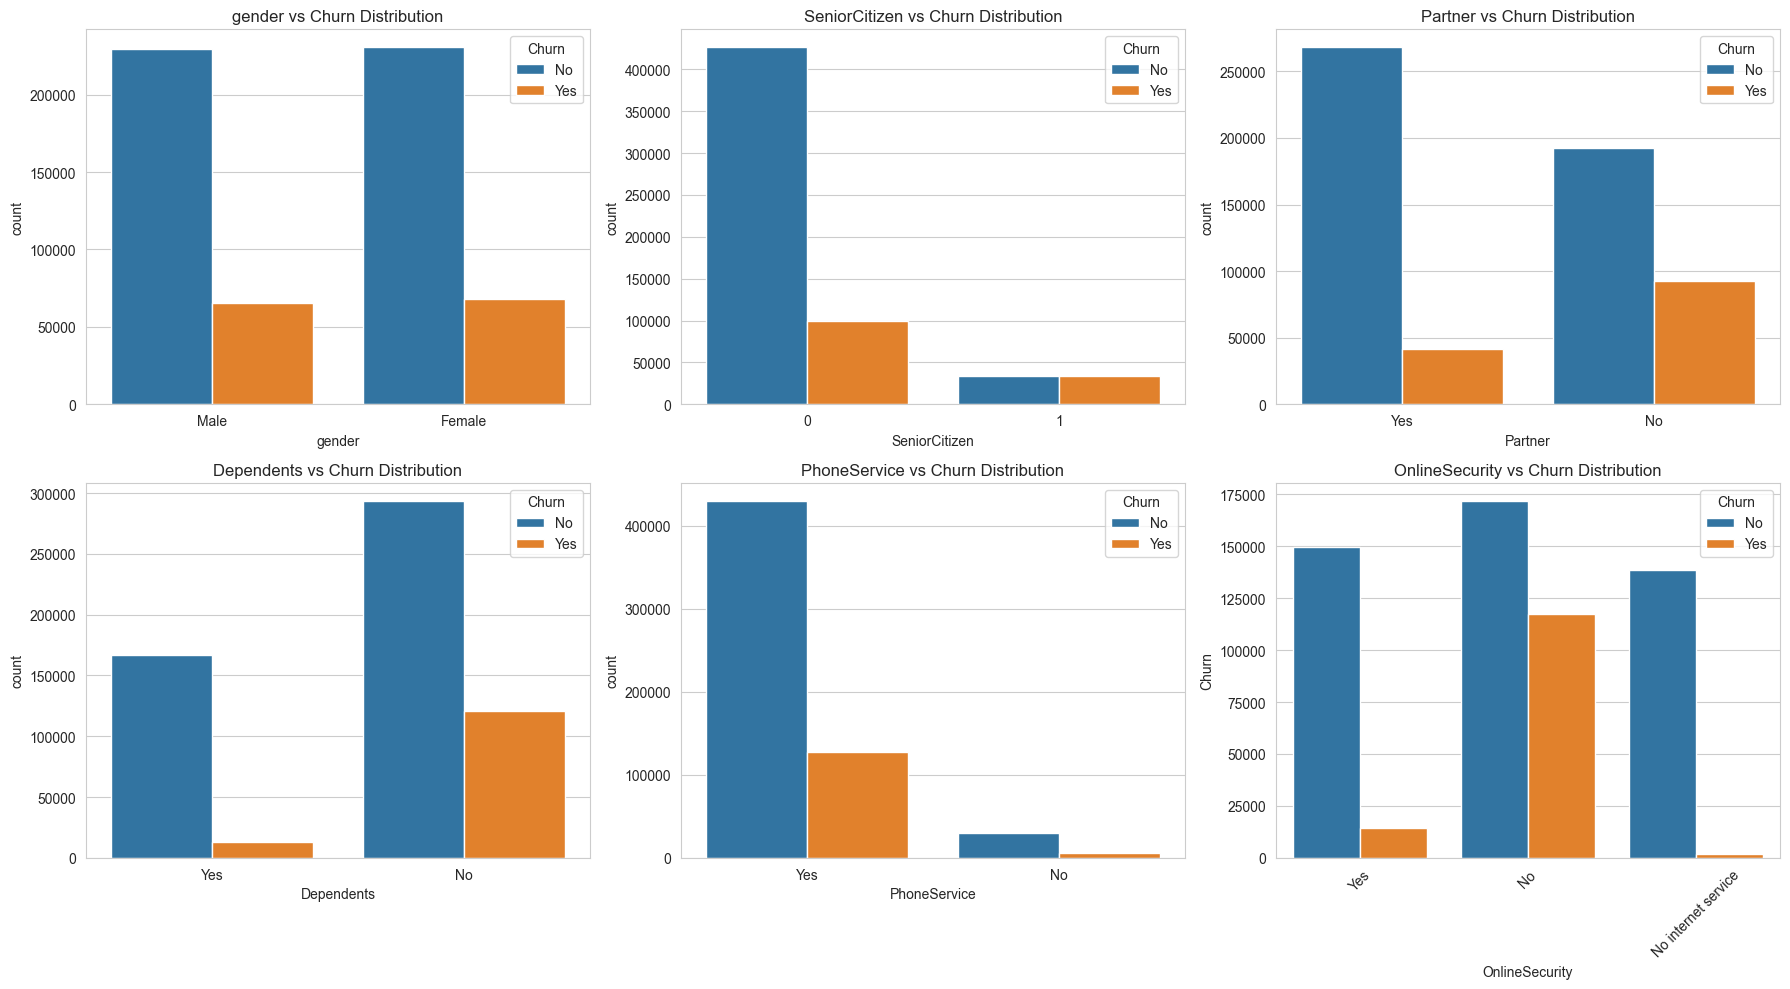

In [27]:
# Bar Plot on gender, SeniorCitizen, Partner, Dependents, PhoneService, OnlineSecurity
plt.rcParams["figure.figsize"] = (15, 8)
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity']

for i, feature in enumerate(features):
    ax = sns.countplot(train[['Churn', feature]], x=f"{feature}", hue='Churn', ax=axes[i])
    ax.set_title(f"{feature} vs Churn Distribution")
    plt.ylabel('Churn')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    
plt.tight_layout()
plt.show()

/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/1456163518.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/1456163518.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/1456163518.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_83267/1456163518.py:16: UserWarning: No artists with labels found to put in legend.  Note that art

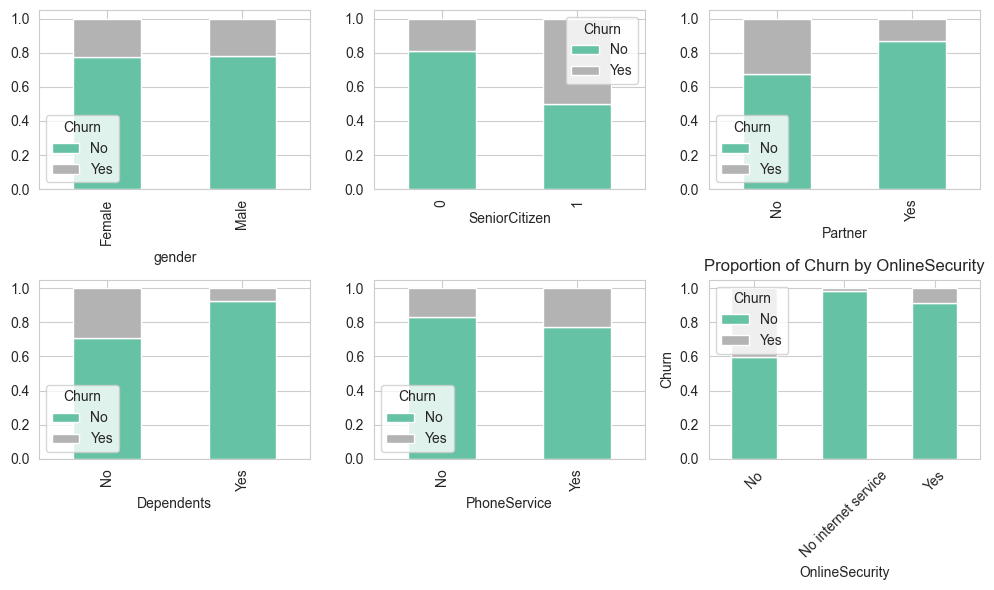

In [22]:
# Stacked Bar Chart on gender, SeniorCitizen, Partner, Dependents, PhoneService, OnlineSecurity
plt.rcParams["figure.figsize"] = (15, 8)
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity']

for i, feature in enumerate(features):
    ct = pd.crosstab(train[feature], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', ax=axes[i])
    plt.title(f"Proportion of Churn by {feature}")
    plt.ylabel('Churn')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    
plt.tight_layout()
plt.show()

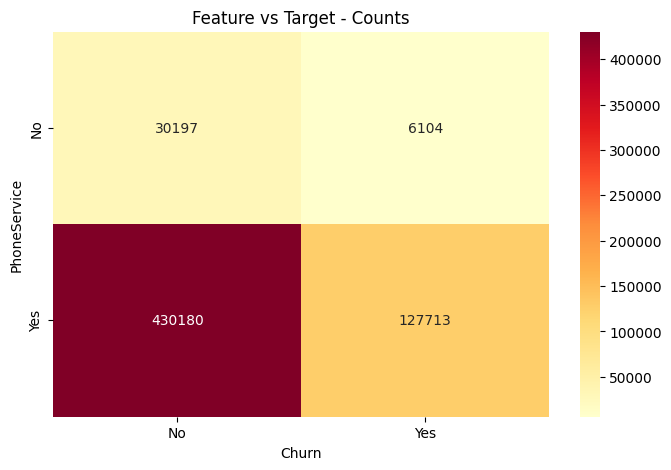

In [18]:
# cross tabulation heatmap
ct = pd.crosstab(train['PhoneService'], train['Churn'])

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Feature vs Target - Counts')
plt.show()

In [30]:
# chi-square
features = [i for i in train.columns if i not in ["Churn"]]
for feature in features:
    ct = pd.crosstab(train[feature], train['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    print(f"{feature:25s} | Chi2: {chi2:10.2f} | p-value: {p_value:.6f} | {'Significant ✅' if p_value < 0.05 else 'Not Significant ❌'}")

id                        | Chi2:  594194.00 | p-value: 0.499390 | Not Significant ❌
gender                    | Chi2:      27.51 | p-value: 0.000000 | Significant ✅
SeniorCitizen             | Chi2:   33193.98 | p-value: 0.000000 | Significant ✅
Partner                   | Chi2:   30944.98 | p-value: 0.000000 | Significant ✅
Dependents                | Chi2:   34329.59 | p-value: 0.000000 | Significant ✅
tenure                    | Chi2:  119835.61 | p-value: 0.000000 | Significant ✅
PhoneService              | Chi2:     721.02 | p-value: 0.000000 | Significant ✅


MultipleLines             | Chi2:    7888.57 | p-value: 0.000000 | Significant ✅
InternetService           | Chi2:  107801.94 | p-value: 0.000000 | Significant ✅
OnlineSecurity            | Chi2:  108175.34 | p-value: 0.000000 | Significant ✅
OnlineBackup              | Chi2:   79195.70 | p-value: 0.000000 | Significant ✅
DeviceProtection          | Chi2:   72256.07 | p-value: 0.000000 | Significant ✅
TechSupport               | Chi2:  103003.06 | p-value: 0.000000 | Significant ✅
StreamingTV               | Chi2:   47108.73 | p-value: 0.000000 | Significant ✅
StreamingMovies           | Chi2:   47173.87 | p-value: 0.000000 | Significant ✅
Contract                  | Chi2:  132429.25 | p-value: 0.000000 | Significant ✅
PaperlessBilling          | Chi2:   48298.22 | p-value: 0.000000 | Significant ✅
PaymentMethod             | Chi2:  134817.83 | p-value: 0.000000 | Significant ✅
MonthlyCharges            | Chi2:   99575.73 | p-value: 0.000000 | Significant ✅
TotalCharges              | 

## Define features and target

In [34]:
models = {
    "Random Forest Classifier": RandomForestClassifier(
                        n_estimators=100,
                        random_state=42
                    ),
    "CatBoost Classifier": CatBoostClassifier(
                        iterations=100,
                        learning_rate=0.1,
                        depth=6,
                        loss_function='MultiClass',
                        verbose=0
                    )
}